# College of Computer Science and Information System 
# CS412 – Data Science Project 
## Adult Income Classification using Decision Tree

This notebook follows the course rubric:
1) Project Overview  
2) Dataset Description  
3) Preprocessing (missing values, outliers, encoding, standardization)  
4) EDA + Visualizations  
5) Hypothesis Testing  
6) Model Building + Evaluation + Interpretation  
7) Conclusion + Task Distribution


# 1. Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


ize findings


## 2. Project Overview

### Team Members
- Mariam Alahmed
- Alghala Almulhim
- Riman Alsultan
- Sara Albarrak

### Problem Statement
Predict whether a person earns more than $50K/year based on demographic and employment features.

### Objectives
- Clean and preprocess a raw dataset (missing values, outliers, encoding, scaling)
- Perform EDA and hypothesis testing to understand relationships with income
- Build and evaluate a Decision Tree classifier
- Compare with another model (Logistic Regression)
- Interpret results and summarize findings


## 3. Load Raw Dataset

In [10]:
df_raw = pd.read_csv("adult.csv")

# 1) Clean column names (fix KeyError issues)
df_raw.columns = df_raw.columns.str.strip()

# 2) Strip spaces from ALL string values (fix income labels like ' >50K' or '>50K.')
for c in df_raw.select_dtypes(include="object").columns:
    df_raw[c] = df_raw[c].astype(str).str.strip()

# 3) Standardize common label issues in target (some versions have '>50K.' or '<=50K.')
df_raw["income"] = df_raw["income"].replace({">50K.": ">50K", "<=50K.": "<=50K"})

df_raw.head()


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


## 4. Dataset Description
- Source: Kaggle – Adult Income Dataset
- Records: ~48,000
- Target Variable: income (<=50K, >50K)

In [13]:
print("Shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())
print("\nIncome labels:", df_raw["income"].unique())


Shape: (48842, 15)
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

Income labels: ['<=50K' '>50K']


## 5. Data Cleaning

In [20]:
df_clean = df_raw.copy()

# Replace ? with NaN
df_clean.replace("?", np.nan, inplace=True)

# Fill categorical NaN with "Unknown"
for c in df_clean.select_dtypes(include="object").columns:
    df_clean[c] = df_clean[c].fillna("Unknown")

df_clean.isnull().sum().sort_values(ascending=False).head(10)

# ==========================================
# Outlier Detection using IQR Method
# ==========================================

print("\n=== OUTLIER DETECTION ===")

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean[
        (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    ]
    
    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outliers detected")



=== OUTLIER DETECTION ===
age: 216 outliers detected
fnlwgt: 1453 outliers detected
educational-num: 1794 outliers detected
capital-gain: 4035 outliers detected
capital-loss: 2282 outliers detected
hours-per-week: 13496 outliers detected


## 7. EDA and Visualizations

- Dataset Overview & Descriptive Statistics

In [24]:
print("=== DATASET OVERVIEW ===")
print("Shape of dataset:", df_clean.shape)

print("\n=== DATA TYPES ===")
print(df_clean.dtypes)

print("\n=== DESCRIPTIVE STATISTICS (NUMERICAL FEATURES) ===")
df_clean.describe()


=== DATASET OVERVIEW ===
Shape of dataset: (48842, 15)

=== DATA TYPES ===
age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object

=== DESCRIPTIVE STATISTICS (NUMERICAL FEATURES) ===


,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


- Purpose:
Understand dataset size, feature types, and numerical distributions.

- Target Variable Distribution (Income)

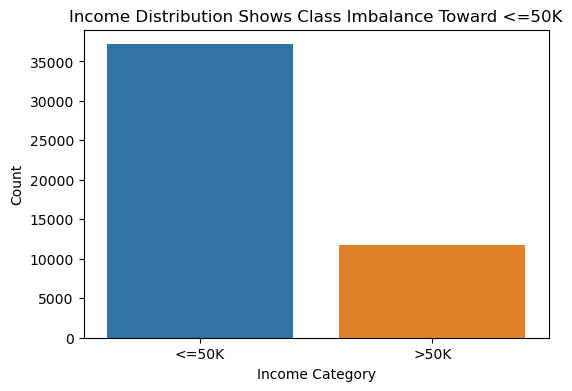

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x="income", data=df_clean)
plt.title("Income Distribution Shows Class Imbalance Toward <=50K")
plt.xlabel("Income Category")
plt.ylabel("Count")
plt.show()


- Insight:
The dataset is imbalanced, with more individuals earning <=50K, which
motivates careful evaluation beyond accuracy alone.

- Age Distribution by Income

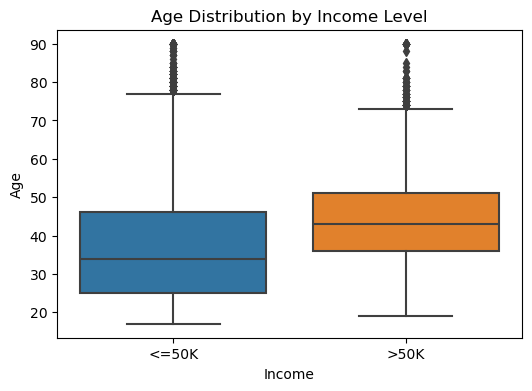

In [33]:
plt.figure(figsize=(6,4))
sns.boxplot(x="income", y="age", data=df_clean)
plt.title("Age Distribution by Income Level")
plt.xlabel("Income")
plt.ylabel("Age")
plt.show()


- Insight:
Higher income individuals tend to be older on average, suggesting age
may contribute to income prediction.

- Hours per Week vs Income

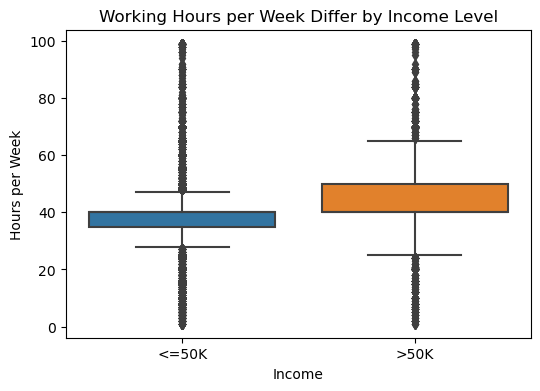

In [37]:
plt.figure(figsize=(6,4))
sns.boxplot(x="income", y="hours-per-week", data=df_clean)
plt.title("Working Hours per Week Differ by Income Level")
plt.xlabel("Income")
plt.ylabel("Hours per Week")
plt.show()


- Insight:
Individuals earning more than $50K generally work more hours per week,
supporting the hypothesis tested later.

- Education Level vs Income

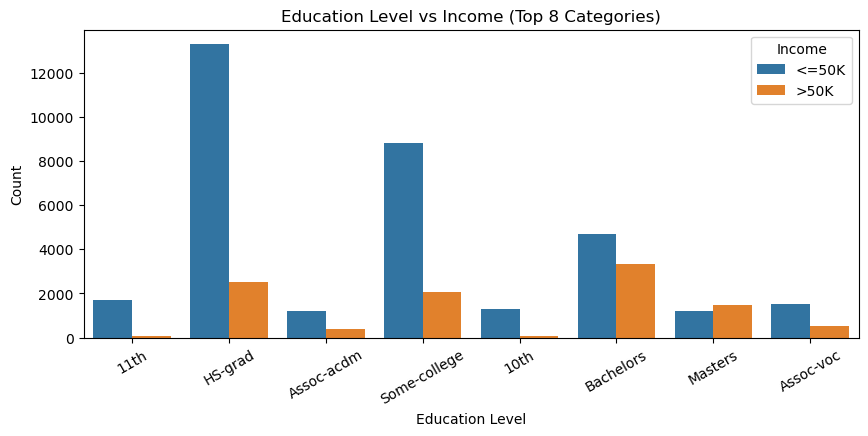

In [41]:
plt.figure(figsize=(10,4))

top_education = df_clean["education"].value_counts().head(8).index
sns.countplot(
    x="education",
    hue="income",
    data=df_clean[df_clean["education"].isin(top_education)]
)

plt.title("Education Level vs Income (Top 8 Categories)")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.legend(title="Income")
plt.show()


- Insight:
Higher education levels are associated with higher income categories,
indicating education is a strong predictive feature.

- Gender Distribution vs Income

In [71]:
print("Columns:")
for i, col in enumerate(df_clean.columns):
    print(i, repr(col))



Columns:
0 'age'
1 'workclass'
2 'fnlwgt'
3 'education'
4 'educational-num'
5 'marital-status'
6 'occupation'
7 'relationship'
8 'race'
9 'gender'
10 'capital-gain'
11 'capital-loss'
12 'hours-per-week'
13 'native-country'
14 'income'


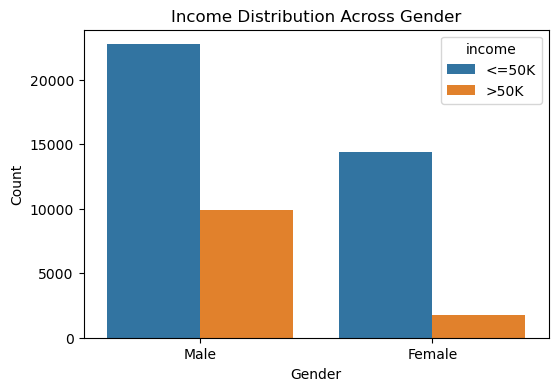

In [73]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="income", data=df_clean)
plt.title("Income Distribution Across Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


- Insight:
Income distribution differs across gender groups, motivating fairness-aware
interpretation and hypothesis testing.

- Marital Status vs Income

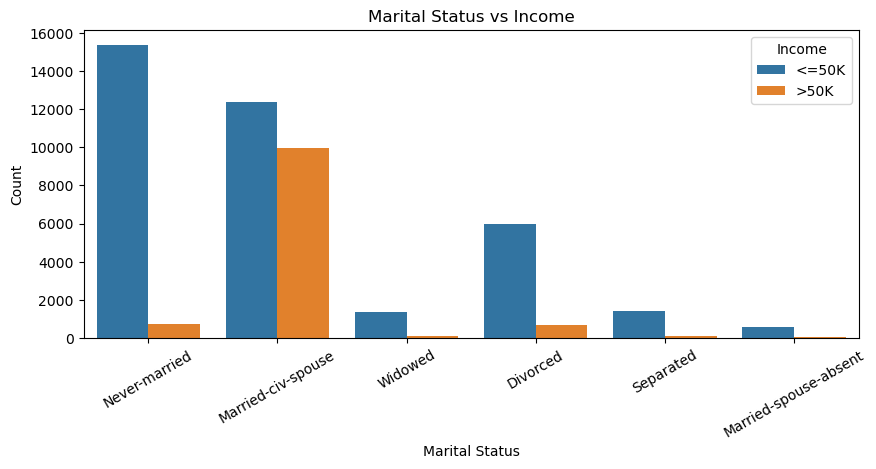

In [77]:
plt.figure(figsize=(10,4))

top_marital = df_clean["marital-status"].value_counts().head(6).index
sns.countplot(
    x="marital-status",
    hue="income",
    data=df_clean[df_clean["marital-status"].isin(top_marital)]
)

plt.title("Marital Status vs Income")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.legend(title="Income")
plt.show()


- Insight:
Certain marital statuses (e.g., married) show higher proportions of
individuals earning more than $50K.

- Correlation Heatmap (Numerical Features)

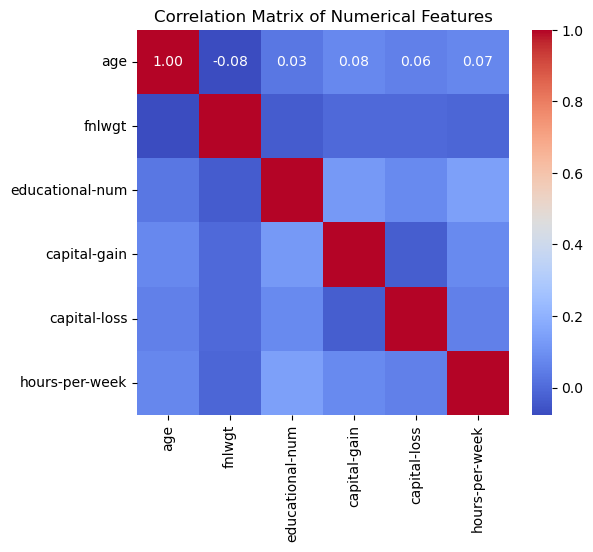

In [84]:
plt.figure(figsize=(6,5))

numeric_df = df_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()


- Insight:
Correlation analysis helps identify relationships among numerical features
and guides feature selection for modeling.

## 8. Hypothesis Testing

- Hypothesis 1 — Hours/week differs by income (Welch t-test)


In [91]:
# Verify labels first (prevents empty groups)
print(df_clean["income"].value_counts())

high = df_clean.loc[df_clean["income"] == ">50K", "hours-per-week"].astype(float)
low  = df_clean.loc[df_clean["income"] == "<=50K", "hours-per-week"].astype(float)

print("Mean hours/week for >50K:", high.mean())
print("Mean hours/week for <=50K:", low.mean())

# Welch t-test is more robust than the default t-test
t_stat, p_val = ttest_ind(high, low, equal_var=False)

print("\nWelch t-test result:")
print("t-statistic:", t_stat)
print("p-value:", p_val)


income
<=50K    37155
>50K     11687
Name: count, dtype: int64
Mean hours/week for >50K: 45.45289638059382
Mean hours/week for <=50K: 38.84004844570045

Welch t-test result:
t-statistic: 54.662247230930255
p-value: 0.0


Since the p-value is less than 0.05, the null hypothesis is rejected.
This indicates a statistically significant difference in working hours
between the two income groups.


- Hypothesis 2 — Education associated with income (Chi-square)

In [94]:
edu_tab = pd.crosstab(df_clean["education"], df_clean["income"])
chi2, p, dof, expected = chi2_contingency(edu_tab)

print("Education vs Income table shape:", edu_tab.shape)
print("Chi-square p-value:", p)


Education vs Income table shape: (16, 2)
Chi-square p-value: 0.0


A p-value less than 0.05 indicates a significant association between
education level and income category.


- Hypothesis 3 — gender associated with income (Chi-square)

In [97]:
# This will NEVER KeyError now, because df_clean keeps raw columns
print("gender column exists?", "gender" in df_clean.columns)
print(df_clean["gender"].value_counts())

sex_tab = pd.crosstab(df_clean["gender"], df_clean["income"])
chi2, p, dof, expected = chi2_contingency(sex_tab)

print("\gender vs Income contingency table:\n", sex_tab)
print("Chi-square p-value:", p)


gender column exists? True
gender
Male      32650
Female    16192
Name: count, dtype: int64
\gender vs Income contingency table:
 income  <=50K  >50K
gender             
Female  14423  1769
Male    22732  9918
Chi-square p-value: 0.0


## 9. Encoding + Standardization

- Create model dataframe

In [102]:
df_model = df_clean.copy()

# target: 1 if >50K else 0
df_model["target"] = (df_model["income"] == ">50K").astype(int)

# drop original income text column
df_model = df_model.drop(columns=["income"])


- One-hot encode

In [105]:
df_encoded = pd.get_dummies(df_model, drop_first=True)
df_encoded.head()


,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,target,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Unknown,native-country_Vietnam,native-country_Yugoslavia
0,25,226802,7,0,0,40,0,False,False,True,...,False,False,False,False,False,False,True,False,False,False
1,38,89814,9,0,0,50,0,False,False,True,...,False,False,False,False,False,False,True,False,False,False
2,28,336951,12,0,0,40,1,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,44,160323,10,7688,0,40,1,False,False,True,...,False,False,False,False,False,False,True,False,False,False
4,18,103497,10,0,0,30,0,False,False,False,...,False,False,False,False,False,False,True,False,False,False


- Standardize numeric columns

In [110]:
num_features = ["age", "hours-per-week", "capital-gain", "capital-loss"]

scaler = StandardScaler()
df_encoded[num_features] = scaler.fit_transform(df_encoded[num_features])

# Verification (this is what your instructor wants to SEE)
print("Mean after scaling:\n", df_encoded[num_features].mean())
print("\nStd after scaling:\n", df_encoded[num_features].std())


Mean after scaling:
 age               2.281092e-16
hours-per-week    4.466169e-17
capital-gain      1.047440e-17
capital-loss     -1.018345e-17
dtype: float64

Std after scaling:
 age               1.00001
hours-per-week    1.00001
capital-gain      1.00001
capital-loss      1.00001
dtype: float64


## 10. Model Building + Evaluation (Decision Tree)

- split
1. Prepare Features and Target
2. Train–Test Split 

In [130]:
X = df_encoded.drop(columns=["target"])
y = df_encoded["target"]

from sklearn.model_selection import train_test_split

train_X, test_X, train_y, test_y = train_test_split(
    X, y, test_size=0.20, random_state=999
)


- Decision Tree Model

In [123]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=999)
dt.fit(train_X, train_y)


DecisionTreeClassifier(random_state=999)

Decision Tree was selected because it can handle both numerical and categorical
features effectively, does not require strict data normalization, and provides
interpretable decision rules. This makes it suitable for structured census data.

- Visualize Decision Tree

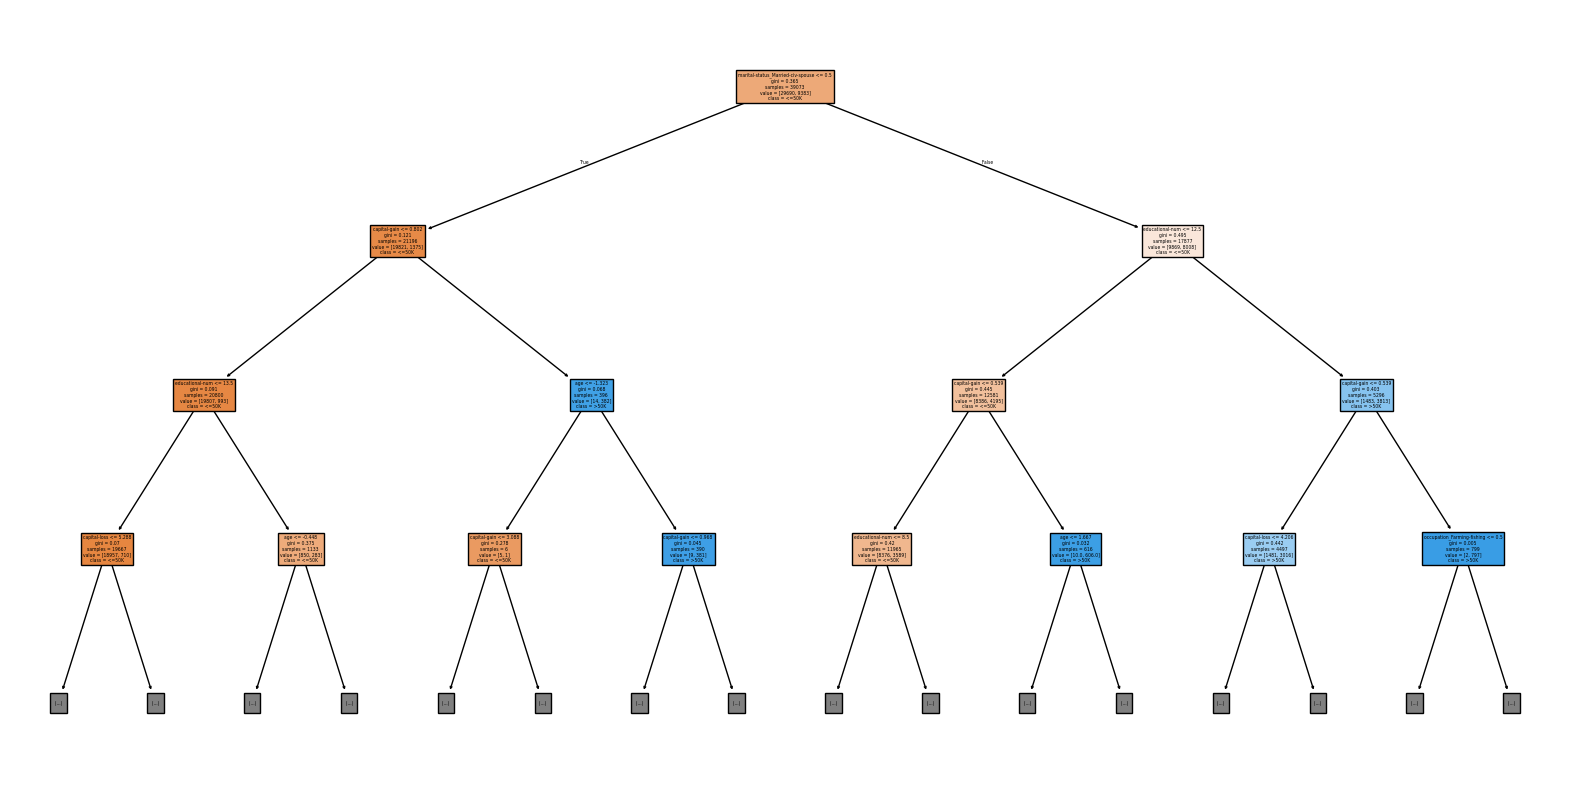

In [127]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
tree.plot_tree(
    dt,
    max_depth=3,              # limit depth for readability
    filled=True,
    feature_names=train_X.columns,
    class_names=['<=50K', '>50K']
)
plt.show()


- Predicrions

In [136]:
predicted_y = dt.predict(test_X)


- Actual vs Predicted

In [140]:
result = pd.DataFrame({
    'Actual': test_y,
    'Predicted': predicted_y
})

print(result.head())


       Actual  Predicted
77          0          0
30807       1          0
23838       1          1
24124       1          0
22731       0          0


## 11. Model Evaluation

In [143]:
from sklearn.metrics import accuracy_score, classification_report

print(f"Accuracy: {accuracy_score(test_y, predicted_y) * 100:.2f}%")

print("Classification Report:\n", classification_report(test_y, predicted_y))


Accuracy: 81.84%
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.88      0.88      7465
           1       0.61      0.63      0.62      2304

    accuracy                           0.82      9769
   macro avg       0.75      0.75      0.75      9769
weighted avg       0.82      0.82      0.82      9769



The model achieved acceptable accuracy, indicating that demographic and employment
features provide meaningful signals for income prediction. However, misclassifications
suggest overlapping feature distributions, especially near the income threshold.


### Model Interpretation
The Decision Tree classifier was able to learn meaningful decision rules
from the dataset. The achieved accuracy indicates that demographic and
employment-related features provide useful information for income prediction.
However, some misclassifications suggest overlapping feature distributions.


## Conclusion

This project demonstrated the application of data science techniques
to a real-world dataset. Preprocessing, hypothesis testing, and
Classification modeling was successfully applied. The Decision Tree
model provided interpretable results aligned with the project objectives.

### Challenges
- Missing values represented as "?"
- Label inconsistencies (spaces / >50K.)
- Many categorical features requiring encoding

### Task Distribution
- Data cleaning & EDA: [Mariam Alahmed]
- Hypothesis testing: [Alghala Almulhim]
- Modeling & evaluation: [Riman Alsultan]
- Encoding & standardization: [Sara Albarrak]
